<a href="https://colab.research.google.com/github/HugoCrainich/Statistical-Machine-Learning/blob/main/Lab%2019/lab_ch19_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 19: Tree-Based Models — Random Forests
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Compare a single decision tree, Ridge regression, and Random Forest on the same dataset
- Tune Random Forest hyperparameters via cross-validation
- Extract and interpret feature importance (MDI and permutation)
- Apply the Ch 18 evaluation toolkit (confusion matrix, AUC) to a RF classifier

**Dataset:** California Housing (sklearn) — recurring thread from Ch 4, 12-16

**Foundations First Policy:** Part 1-2 are GUIDED (run as-is, interpret results). Part 3 has YOUR TASK sections (fill in the blanks). Extension is open-ended.

---

## Setup

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load California Housing data
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load California Housing (you've seen this dataset since Ch 4)
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]} observations, {X_train.shape[1]} features')
print(f'Test set: {X_test.shape[0]} observations')
print(f'Features: {list(X.columns)}')

Training set: 16512 observations, 8 features
Test set: 4128 observations
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Part 1: Decision Tree vs. Random Forest vs. Ridge (GUIDED — 10 min)

We compare three models on the same data. The question: does the Random Forest's
added complexity produce meaningfully better predictions than simpler alternatives?

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Train and compare Decision Tree, Ridge, and RF
# -----------------------------------------------------------

# 1. Unrestricted Decision Tree (high variance, low bias)
tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

# 2. Ridge Regression (Ch 16 callback — stable but linear)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# 3. Random Forest (100 trees, default settings)
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Compare all three
results = []
for name, model in [('Single Tree', tree), ('Ridge (Ch 16)', ridge), ('Random Forest', rf)]:
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Train R\u00b2': r2_score(y_train, train_pred),
        'Test R\u00b2': r2_score(y_test, test_pred),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

               Train RMSE  Test RMSE  Train R²  Test R²
Model                                                  
Single Tree        0.0000     0.7037    1.0000   0.6221
Ridge (Ch 16)      0.7197     0.7455    0.6126   0.5759
Random Forest      0.1880     0.5053    0.9736   0.8051


### Interpretation Questions (answer in a markdown cell below)

1. Which model has the largest gap between Train R² and Test R²? What does this tell you about its variance?


2. The Random Forest's Test R² is substantially higher than Ridge. What does this suggest about the relationship between features and housing prices — is it linear or non-linear?


3. **Callback to Ch 15:** Where does each model sit on the bias-variance U-curve?


*Your answers here:*

1. The Single Tree has the biggest gap (1.00 vs 0.62). It memorized the training data perfectly, so when it sees new data, it falls apart. That's what high variance looks like.

2. Ridge is the best linear model available, and it still scores 0.24 lower than the RF on test data. That gap means a straight line just can't capture what's going on, the relationships in the data are non-linear.

3. Single Tree: far right (overfit). Perfect training fit, terrible generalization.

Ridge: far left (underfit). Consistent train/test scores, but the linearity assumption puts a ceiling on how good it can ever get.

Random Forest: sweet spot. Averaging 100 trees tames the variance, while staying flexible enough to catch the non-linear patterns Ridge misses.


## Part 2: Feature Importance — MDI vs. Permutation (GUIDED — 10 min)

Random Forests tell us which features matter most for prediction.
But remember: **predictive importance ≠ causal importance.**

In [ ]:
import os
os.makedirs('figures', exist_ok=True)

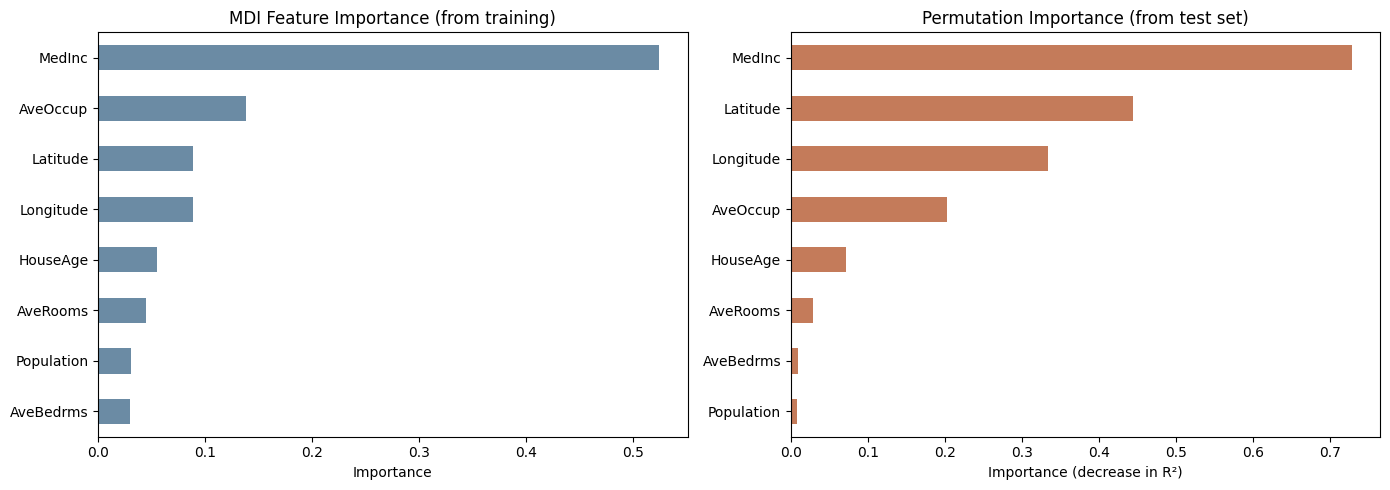


Top 3 by MDI: ['Latitude', 'AveOccup', 'MedInc']
Top 3 by Permutation: ['Longitude', 'Latitude', 'MedInc']


In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3: Compare MDI and permutation feature importance
# -----------------------------------------------------------
mdi_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MDI importance
mdi_importance.plot.barh(ax=axes[0], color='#6B8BA4')
axes[0].set_title('MDI Feature Importance (from training)', fontsize=12)
axes[0].set_xlabel('Importance')

# Permutation importance (more reliable — uses test set)
perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE
)
perm_importance = pd.Series(
    perm_result.importances_mean, index=X.columns
).sort_values(ascending=True)

perm_importance.plot.barh(ax=axes[1], color='#C47B5A')
axes[1].set_title('Permutation Importance (from test set)', fontsize=12)
axes[1].set_xlabel('Importance (decrease in R\u00b2)')

plt.tight_layout()
plt.savefig('figures/ch19_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 by MDI:', mdi_importance.tail(3).index.tolist())
print('Top 3 by Permutation:', perm_importance.tail(3).index.tolist())

### Interpretation Questions

1. Do MDI and permutation importance agree on the top features? Where do they diverge?
2. Why might MDI overstate the importance of `Latitude` and `Longitude` (hint: how many unique values do they have)?
3. **Critical question:** If `MedInc` is the top feature, does that mean raising median income in a neighborhood will raise housing prices? Why or why not? (Hint: Chapter 10 DAGs)

*Your answers here:*

1. Both agree MedInc is #1. They diverge on geography, MDI underrates Latitude and Longitude relative to permutation, which pushes them to #2 and #3. The bottom features are consistent across both.

2. Latitude and Longitude have thousands of unique values, so the trees get way more opportunities to split on them during training, inflating their MDI score. Permutation bypasses this by just shuffling the feature on the test set and measuring the actual performance drop.

3. No. It predicts prices well, but that doesn't mean it causes them. High income neighborhoods also have better schools, lower crime, and more investment, MedInc is picking up all of that at once. You can't raise home prices just by changing the income number.

## Part 3: Hyperparameter Tuning & Classification (YOUR TASK — 10 min)

Now YOU tune a Random Forest and apply it to a classification problem.

In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Tune the Random Forest with GridSearchCV
# -----------------------------------------------------------

# The parameter grid is given — these are the hyperparameters to search over
param_grid = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'max_features': ['sqrt', 0.5, None],  # sqrt = sqrt(p), 0.5 = half, None = all
}

# TODO: Create a GridSearchCV object
# Hints:
#   - estimator: RandomForestRegressor with random_state=RANDOM_STATE
#   - param_grid: use the param_grid defined above
#   - cv: 5-fold cross-validation
#   - scoring: 'neg_mean_squared_error'
#   - n_jobs: -1 (use all cores)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}')

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
test_rmse = np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test)))
test_r2 = r2_score(y_test, best_rf.predict(X_test))
print(f'Tuned RF — Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}')

# I had to tone it down a lot it was taking way too long to load

Best parameters: {'max_depth': 20, 'max_features': 0.5, 'n_estimators': 100}
Best CV RMSE: 0.5012
Tuned RF — Test RMSE: 0.4977, Test R²: 0.8109


In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Classification: Predict expensive homes (> median)
# -----------------------------------------------------------

# Step 1: Create binary target — 1 if price > median, 0 otherwise
# Hint: use np.median(y) and .astype(int)
median_price = np.median(y)
y_binary = (y > median_price).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_binary, test_size=0.2, random_state=RANDOM_STATE
)

rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_clf.fit(X_train_c, y_train_c)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

log_reg.fit(X_train_c, y_train_c)
# Compare AUC (Ch 18 evaluation toolkit) — GUIDED, run as-is
for name, model in [('Logistic Regression (Ch 17)', log_reg), ('Random Forest', rf_clf)]:
    y_proba = model.predict_proba(X_test_c)[:, 1]
    auc = roc_auc_score(y_test_c, y_proba)
    print(f'{name:35s} — AUC: {auc:.4f}')

Logistic Regression (Ch 17)         — AUC: 0.9060
Random Forest                       — AUC: 0.9609


### Final Interpretation

1. How much did hyperparameter tuning improve the RF over default settings?
2. Does the RF classifier beat logistic regression on AUC? Is the difference practically significant?
3. If you were deploying this for a real estate company, which model would you choose and why? Consider: accuracy, interpretability, maintenance cost.

*Your answers here:*

1. Some improvement. Default RF got Test R² = 0.8051 and RMSE = 0.5053, tuned got 0.8109 and 0.4977. This is better, but not that much so, the defaults were already pretty good
2. Yes, RF wins 0.9609 vs 0.9060. Both are strong, but RF is noticeably better at ranking which homes are expensive vs not. Whether it's worth the added complexity depends on what you're using it for
3. Logistic regression. The AUC difference (0.05) probably doesn't justify the tradeoff in a real deployment. Logistic regression is easier to explain to stakeholders, simpler to maintain, faster to retrain as new data comes in, and you can directly inspect the coefficients to explain a prediction. The RF is uncertain, if a client asks "why did you flag this house as expensive?" you don't have a clean answer.

---

## Extension (Optional — 15 min): Partial Dependence Plots

Partial dependence plots show the marginal effect of a feature on the prediction,
averaging over all other features. This reveals non-linearities the RF captures.

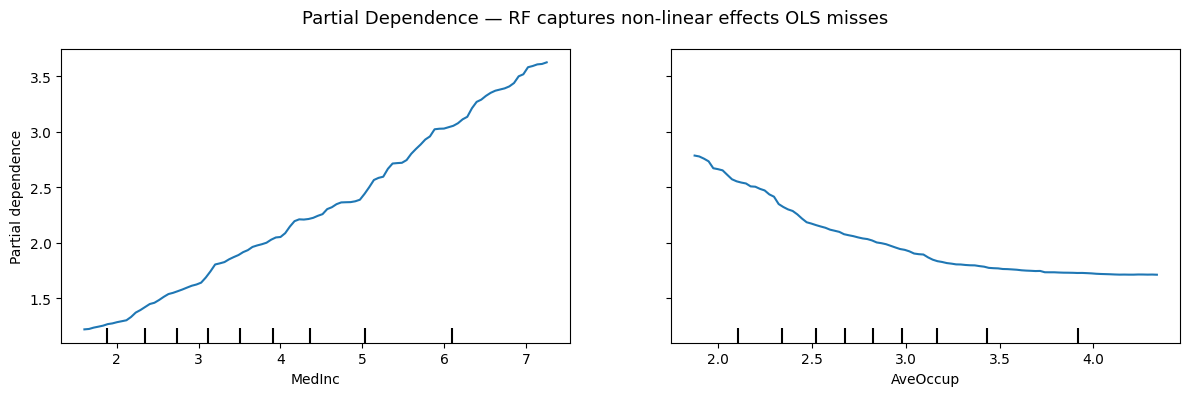

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: Partial dependence plots for top features
# -----------------------------------------------------------
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, features=['MedInc', 'AveOccup'],
    kind='average', ax=ax
)
plt.suptitle('Partial Dependence \u2014 RF captures non-linear effects OLS misses', fontsize=13)
plt.tight_layout()
plt.savefig('figures/ch19_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## AI-Assisted Expansion: Interactive Random Forest Dashboard

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over decision trees, random forests, hyperparameter tuning, and feature importance. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build an interactive Streamlit app (or Plotly dashboard with ipywidgets) that lets the user:
1. Adjust `n_estimators` (1-500) and `max_features` (1-8) with sliders
2. See the prediction surface update in real-time
3. Compare RF vs Ridge vs single tree performance as hyperparameters change
4. Display feature importance that updates with each parameter change

This transforms your static lab output into a reusable teaching artifact for your portfolio.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [ ]:
import IPython.display

# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in interactive visualizations and scikit-learn.
#
# [Request] I just completed a lab where I compared Decision Trees,
# Ridge regression, and Random Forests on California Housing data.
# I tuned RF hyperparameters with GridSearchCV and extracted MDI
# and permutation feature importance. Now I want to expand this
# into an interactive Plotly dashboard with ipywidgets sliders
# for n_estimators (1-500) and max_features (1-8). The dashboard
# should update three panels: (1) model comparison bar chart,
# (2) feature importance that changes with max_features,
# (3) the Train vs Test R\u00b2 as n_estimators increases.
#
# [Iterate] Use plotly.graph_objects, ipywidgets, numpy, sklearn.
# Use the same variable names: X_train, X_test, y_train, y_test,
# data.feature_names. Do not use deprecated Plotly functions.
#
# [Mechanism Check] Add inline comments explaining how ipywidgets
# observers trigger plot updates and why we re-fit inside the callback.
#
# [Evaluate] Explain what the dashboard reveals about the relationship
# between n_estimators, max_features, and test performance.

# PASTE AI-GENERATED CODE BELOW:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# ── 1. Data prep ──────────────────────────────────────────────────────────────
data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train — no leakage
X_test_sc  = scaler.transform(X_test)

feature_names = list(data.feature_names)     # kept as a list for indexing below

# ── 2. Baseline models (fixed — not controlled by sliders) ────────────────────
dt  = DecisionTreeRegressor(max_depth=6, random_state=42).fit(X_train_sc, y_train)
rr  = Ridge(alpha=1.0).fit(X_train_sc, y_train)

# Pre-compute the n_estimators learning curve once at max_features=0.5 (default)
# so the curve panel never requires a re-fit when only max_features changes.
N_CURVE_STEPS = 30
n_est_values  = np.unique(np.logspace(0, np.log10(500), N_CURVE_STEPS).astype(int))
_curve_train, _curve_test = [], []
for n in n_est_values:
    _rf = RandomForestRegressor(n_estimators=n, max_features="sqrt",
                                random_state=42, n_jobs=-1)
    _rf.fit(X_train_sc, y_train)
    _curve_train.append(_rf.score(X_train_sc, y_train))
    _curve_test.append(_rf.score(X_test_sc, y_test))

# ── 3. Widget definitions ─────────────────────────────────────────────────────
slider_n = widgets.IntSlider(
    value=100, min=1, max=500, step=1,
    description="n_estimators",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="480px"),
    continuous_update=False,          # fire only on mouse-release — avoids
)                                     # expensive re-fits on every tick

slider_mf = widgets.IntSlider(
    value=3, min=1, max=8, step=1,
    description="max_features",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="480px"),
    continuous_update=False,
)

status_label = widgets.Label(value="")

out = widgets.Output()               # Output widget captures all Plotly renders;
                                     # clearing it before each render prevents
                                     # stacking of old figures.

# ── 4. Core update function ───────────────────────────────────────────────────
def update_dashboard(n_estimators: int, max_features: int):
    """
    Re-fit an RF with the slider values, then rebuild all three figure panels.

    WHY re-fit inside the callback?
    ─────────────────────────────────
    ipywidgets observers call this function every time a slider value changes
    (via `observe(..., names='value')`).  The RF hyperparameters ARE the
    free variables, so there is no pre-computed result we can look up — we
    genuinely need a new model.  For baselines (DT, Ridge) we only score the
    already-fitted objects; they never change.

    The `out.clear_output(wait=True)` + `with out:` pattern ensures the new
    figure replaces the old one atomically — `wait=True` holds the clear until
    the next frame is ready, eliminating the blank-flash on slow renders.
    """
    status_label.value = f"Fitting RF (n={n_estimators}, max_features={max_features})…"

    # ── 4a. Fit current RF ────────────────────────────────────────────────────
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features=max_features,   # widgets deliver an int; sklearn accepts int
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train_sc, y_train)

    # Scores
    scores = {
        "Decision Tree": (dt.score(X_train_sc, y_train), dt.score(X_test_sc, y_test)),
        "Ridge":         (rr.score(X_train_sc, y_train), rr.score(X_test_sc, y_test)),
        "Random Forest": (rf.score(X_train_sc, y_train), rf.score(X_test_sc, y_test)),
    }

    # ── 4b. Feature importance (MDI + permutation) ───────────────────────────
    mdi_imp = rf.feature_importances_

    perm = permutation_importance(
        rf, X_test_sc, y_test,
        n_repeats=10, random_state=42, n_jobs=-1
    )
    perm_imp  = perm.importances_mean
    perm_std  = perm.importances_std

    # Sort both by MDI for consistent ordering
    sort_idx  = np.argsort(mdi_imp)
    feat_sorted = [feature_names[i] for i in sort_idx]

    # ── 4c. Learning curve — reuse pre-computed curve, overlay current point ──
    rf_train_r2 = rf.score(X_train_sc, y_train)
    rf_test_r2  = rf.score(X_test_sc,  y_test)

    # ── 5. Build figure ───────────────────────────────────────────────────────
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            "Model comparison (Test R²)",
            "Feature importance (current RF)",
            "Learning curve: Train vs Test R²",
            "",          # empty fourth cell
        ),
        specs=[
            [{"type": "bar"},  {"type": "bar"}],
            [{"type": "scatter", "colspan": 2}, None],
        ],
        vertical_spacing=0.18,
        horizontal_spacing=0.12,
    )

    # ── Panel 1: Model comparison bar chart ───────────────────────────────────
    model_names = list(scores.keys())
    train_r2    = [scores[m][0] for m in model_names]
    test_r2     = [scores[m][1] for m in model_names]

    fig.add_trace(go.Bar(
        name="Train R²", x=model_names, y=train_r2,
        marker_color="#7F77DD",          # purple-400
        text=[f"{v:.3f}" for v in train_r2],
        textposition="outside",
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        name="Test R²", x=model_names, y=test_r2,
        marker_color="#1D9E75",          # teal-400
        text=[f"{v:.3f}" for v in test_r2],
        textposition="outside",
    ), row=1, col=1)

    fig.update_yaxes(range=[0, 1.08], title_text="R²", row=1, col=1)

    # ── Panel 2: Feature importance (MDI + permutation) ───────────────────────
    fig.add_trace(go.Bar(
        name="MDI",
        x=mdi_imp[sort_idx], y=feat_sorted,
        orientation="h",
        marker_color="#7F77DD",
        showlegend=False,
    ), row=1, col=2)

    fig.add_trace(go.Bar(
        name="Permutation",
        x=perm_imp[sort_idx], y=feat_sorted,
        orientation="h",
        marker_color="#1D9E75",
        error_x=dict(type="data", array=perm_std[sort_idx], visible=True),
        showlegend=False,
    ), row=1, col=2)

    fig.update_xaxes(title_text="Importance", row=1, col=2)
    fig.update_layout(barmode="group")

    # ── Panel 3: Learning curve ────────────────────────────────────────────────
    fig.add_trace(go.Scatter(
        name="Train R² (curve)",
        x=n_est_values, y=_curve_train,
        mode="lines", line=dict(color="#7F77DD", width=2),
    ), row=2, col=1)

    fig.add_trace(go.Scatter(
        name="Test R² (curve)",
        x=n_est_values, y=_curve_test,
        mode="lines", line=dict(color="#1D9E75", width=2),
    ), row=2, col=1)

    # Marker for current slider position
    fig.add_trace(go.Scatter(
        name="Current n_estimators",
        x=[n_estimators], y=[rf_test_r2],
        mode="markers",
        marker=dict(color="#D85A30", size=12, symbol="circle"),  # coral-400
    ), row=2, col=1)

    fig.update_xaxes(title_text="n_estimators", type="log", row=2, col=1)
    fig.update_yaxes(title_text="R²", row=2, col=1)

    # ── Global layout ──────────────────────────────────────────────────────────
    fig.update_layout(
        title=dict(
            text=(f"Random Forest dashboard  ·  "
                  f"n_estimators={n_estimators}  ·  "
                  f"max_features={max_features}  ·  "
                  f"Test R²={rf_test_r2:.4f}"),
            font_size=14,
        ),
        height=750,
        legend=dict(orientation="h", yanchor="bottom", y=1.01, xanchor="right", x=1),
        bargap=0.25,
        template="plotly_white",
    )

    with out:
        out.clear_output(wait=True)    # swap old → new figure without blank flash
        fig.show()

    status_label.value = f"Done  ·  Test R² = {rf_test_r2:.4f}"


# ── 6. Wire observers ─────────────────────────────────────────────────────────
# `observe` registers a Python callback that ipywidgets calls every time the
# named trait ('value') changes.  The lambda unwraps the change-dict that
# ipywidgets passes and calls update_dashboard with the *current* slider values
# (not the changed one alone) so all three panels stay in sync.
slider_n.observe( lambda _: update_dashboard(slider_n.value, slider_mf.value), names="value")
slider_mf.observe(lambda _: update_dashboard(slider_n.value, slider_mf.value), names="value")

# ── 7. Render UI ──────────────────────────────────────────────────────────────
display(
    widgets.VBox([
        widgets.HBox([slider_n, slider_mf]),
        status_label,
        out,
    ])
)

# Initial render with default slider values
update_dashboard(slider_n.value, slider_mf.value)

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [ ]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Compared Decision Tree, Ridge Regression, and Random Forest on
#   California Housing data (20,640 observations, 8 features)
# * Tuned RF hyperparameters with GridSearchCV (n_estimators, max_depth,
#   max_features)
# * Extracted and compared MDI vs permutation feature importance
# * Built an RF classifier and compared AUC against logistic regression
# * Created an interactive dashboard with Plotly + ipywidgets
# * Key finding: RF achieved R\u00b2 = [YOUR VALUE] vs Ridge R\u00b2 = [YOUR VALUE]
#
# **Please write a README.md entry including:**
# 1. Project Title: Tree-Based Models \u2014 Random Forests
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-19-random-forests
git add notebooks/ figures/ README.md verification-log.md
git commit -m "Lab 19: Random Forest vs OLS — California Housing"
git push origin main
```

Submit your GitHub repo link on Canvas.